In [7]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
%run ./TbIG_Experiment_Functions.ipynb

In [8]:
datas=[]
datas=(pd.read_csv('SQUID_csv/TbIG_300K_demagnetize_test_Feb232024.dat.csv', header=None),
             pd.read_csv('SQUID_csv/TbIG_275K_mag_temp_Feb232024.dat.csv', header=None),
            pd.read_csv('SQUID_csv/TbIG_225K_mag_temp_Feb232024.dat.csv', header=None),
            pd.read_csv('SQUID_csv/TbIG_200K_mag_temp_Feb232024.dat.csv', header=None))
dvarnish = pd.read_csv('SQUID_csv/GE_Varnish_high_field.dat.csv', header=None)

In [9]:
temps=[]
mags=[]
temperrors=[]
magerrors=[]
for data in datas:
    mintemp = np.float64(data[35][50:61])
    maxtemp = np.float64(data[36][50:61])
    temp = (mintemp+maxtemp)/2
    mag = np.float64(data[4][50:61])

    magerror = np.float64(data[5][50:61])
    temperror = (-mintemp+maxtemp)/2
    temperror=[sorted(set(temperror))[1] if temperror[i]==0 else temperror[i] for i in np.arange(len(temperror))]

    temps.append(temp)
    if mag[0]<0:
        mags.append(mag)
    else:
        mags.append(mag)
    temperrors.append(temperror)
    magerrors.append(magerror)




Estimated T_comp for 300K: 255.79 +/- 0.43
Estimated T_comp for 275K: 255.71 +/- 0.39
Estimated T_comp for 225K: 256.35 +/- 0.45
Estimated T_comp for 200K: 256.37 +/- 0.39
Total estimated T_comp: 256.05 +/- 0.31


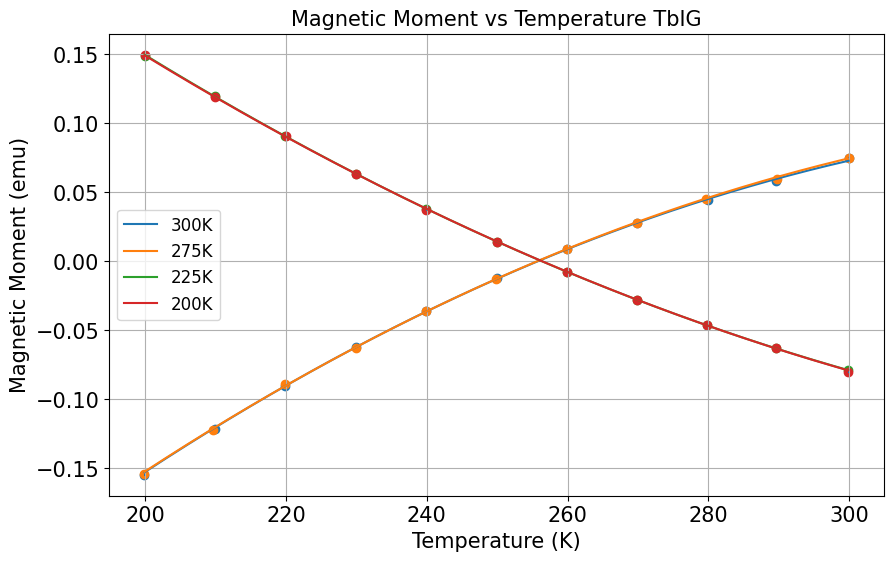

In [10]:
# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))

# Create an inset with a different range in the same figure
# Arguments are: [left, bottom, width, height] in figure coordinates (0 to 1)
#ax_inset = fig.add_axes([0.5, 0.2, 0.1, 0.1])

SMALL_SIZE = 8
MEDIUM_SIZE = 12
BIGGER_SIZE = 15
huge=25

labels=["300K", "275K", "225K", "200K"]
#labels=[300, 275, 256, 225, 200]
betas=[]
plots=[]
comps=[]
deltas=[]

for i in np.arange(4):
    x,y,sigma_x,sigma_y = temps[i], mags[i], temperrors[i], magerrors[i]
    results=analysis(x, y, sigma_x, sigma_y)
    comps.append(results[2])
    deltas.append(results[3])
    beta=results[0]
    betas.append(beta)
    ax.scatter(x, y)
    ax.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    newx=np.arange(min(x), max(x), .1)
    plot,=ax.plot(newx,beta[0]*newx**2+beta[1]*newx+beta[2],label=labels[i])
    plots.append(plot)
    #ax_inset.scatter(x, y)
    #ax_inset.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    print(f"Estimated T_comp for {labels[i]}: {np.round(results[2],2)} +/- {np.round(results[3],2)}")

# Total uncertainty is (max-min)/2 divided by sqrt of sample number
print(f"Total estimated T_comp: {np.round(np.mean(comps),2)} +/- {np.round(np.std(comps),2)}")

plt.rc('figure', titlesize=huge)  # fontsize of the figure title

# Set plot title and axes labels
ax.set(title = "Magnetic Moment vs Temperature TbIG",
       xlabel = "Temperature (K)",
       ylabel = "Magnetic Moment (emu)")


plt.rc('font', size=huge)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=huge)  # fontsize of the figure title

x1, x2, y1, y2 = 299.992, 300.006, 0.07492, 0.07496  # subregion of the original image

# Plot the same data in the inset, but zoomed in
# Zoom in between x=2 and x=3
#ax_inset.set_xlim(x1, x2)
#ax_inset.set_ylim(y1, y2)
#ax_inset.set_xticks([])
#ax_inset.set_yticks([])
#ax_inset.set_title('10k Zoom')


ax.legend(loc='center left')

ax.grid()

#plt.savefig('TbIG_Tcomp_4.png',dpi=200)

plt.show(plots)



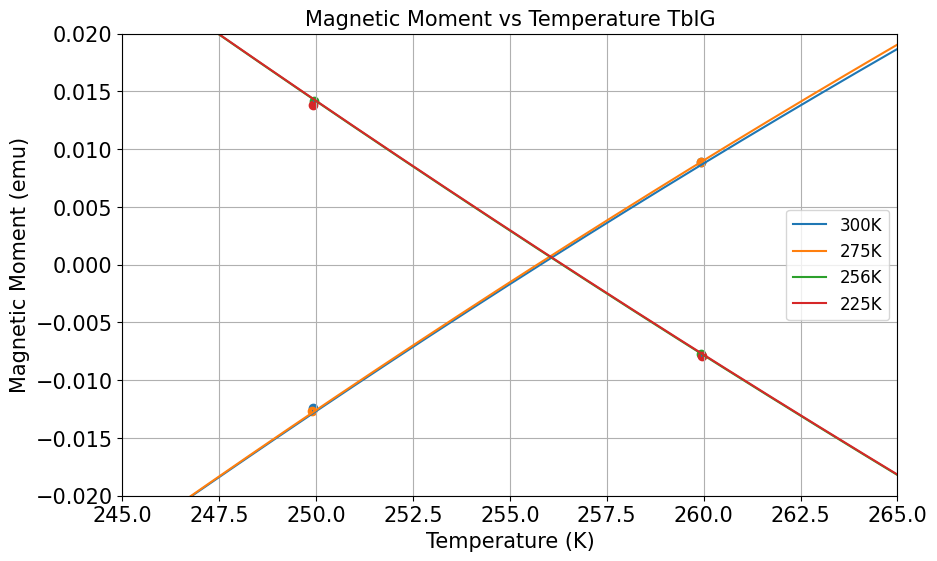

In [12]:
# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))

labels=["300K", "275K", "256K", "225K", "200K"]
#labels=[300, 275, 256, 225, 200]
betas=[]
plots=[]
comps=[]
deltas=[]

for i in np.arange(4):
    x,y,sigma_x,sigma_y = temps[i], mags[i], temperrors[i], magerrors[i]
    results=analysis(x, y, sigma_x, sigma_y)
    comps.append(results[2])
    deltas.append(results[3])
    beta=results[0]
    betas.append(beta)
    ax.scatter(x, y)
    ax.errorbar(x, y, xerr=sigma_x, yerr=sigma_y, fmt='none')
    newx=np.arange(min(x), max(x), .1)
    plot,=ax.plot(newx,beta[0]*newx**2+beta[1]*newx+beta[2],label=labels[i])
    plots.append(plot)
    #print(f"Estimated T_comp for {labels[i]}: {np.round(results[2],2)} +/- {np.round(results[3],2)}")

# Total uncertainty is (max-min)/2 divided by sqrt of sample number
#print(f"Total estimated T_comp: {np.round(np.mean(comps),2)} +/- {np.round(np.std(comps),2)}")

# Set plot title and axes labels
ax.set(title = "Magnetic Moment vs Temperature TbIG",
       xlabel = "Temperature (K)",
       ylabel = "Magnetic Moment (emu)")

ax.set_xlim(245, 265)
ax.set_ylim(-.02,0.02)

ax.legend()

ax.grid()

plt.savefig('TbIG_Zoomed_Tcomp.png',dpi=200)

plt.show(plots)